In [2]:
import yfinance as yf
import pandas as pd

df = yf.download("BTC-USD", start="2017-01-01")


[*********************100%***********************]  1 of 1 completed


In [3]:
# Xem 5 dòng đầu tiên của dataset
df.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008
2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992
2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000
2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984
2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008


In [4]:
# Xem thông tin tổng quan về dataset
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3356 entries, 2017-01-01 to 2026-03-10
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   3356 non-null   float64
 1   (High, BTC-USD)    3356 non-null   float64
 2   (Low, BTC-USD)     3356 non-null   float64
 3   (Open, BTC-USD)    3356 non-null   float64
 4   (Volume, BTC-USD)  3356 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 157.3 KB


In [5]:
# Xem thống kê mô tả của dataset
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,3356.000000,3356.000000,3356.000000,3356.000000,3.356000e+03
mean,34503.726497,35174.696410,33746.667260,34484.267903,2.749884e+10
std,32490.913422,33020.579959,31913.371926,32490.719579,2.263892e+10
min,777.757019,823.307007,755.755981,775.177979,6.085170e+07
25%,8164.680420,8289.237549,7929.757568,8161.269165,1.087277e+10
50%,23138.622070,23518.148438,22716.174805,23120.910156,2.386838e+10
75%,55755.476562,57284.095703,53689.908203,55424.416992,3.816633e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [6]:
# Sử dụng giá trị index ở level 0 (Close, Open, High, Low, Volume) làm tên cột
df.columns = df.columns.get_level_values(0) 
df.columns = [col.lower() for col in df.columns]  # chuyển tên cột thành chữ thường
df.sort_values("Date", inplace=True)  # sắp xếp theo cột date

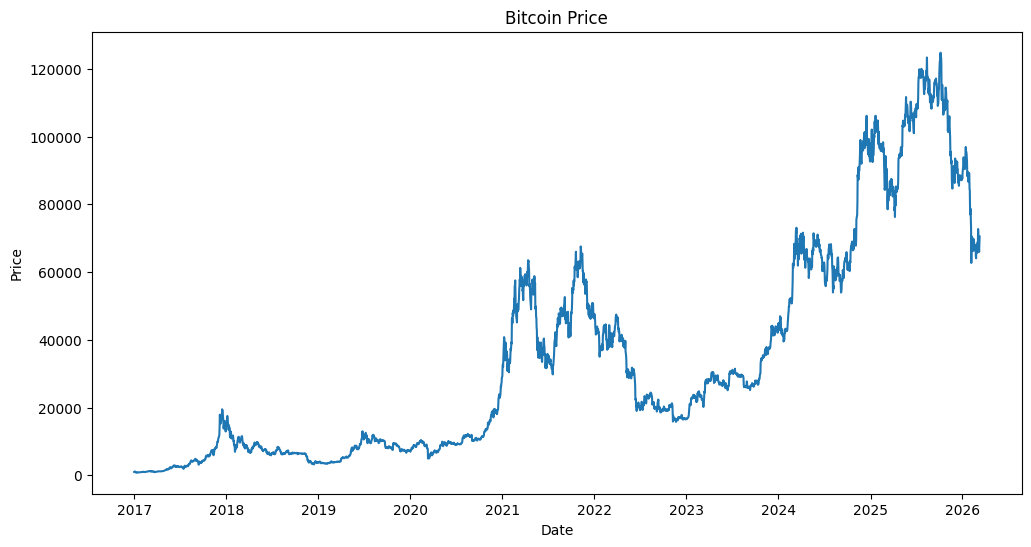

In [7]:
# Vẽ biểu đồ giá Bitcoin theo thời gian từ năm 2017 đến nay

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df.index, df["close"])
plt.title("Bitcoin Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()



In [8]:
import numpy as np

# Tính return hàng ngày
df["daily_return"] = np.log(df["close"] / df["close"].shift(1))
df.dropna(inplace=True)  # loại bỏ các giá trị NaN

In [9]:
df

,close,high,low,open,volume,daily_return
Date,,,,,,
2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992,0.023193
2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000,0.021389
2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984,0.100960
2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008,-0.130575
2017-01-06,902.200989,1046.810059,883.943970,1014.239990,351876000,-0.116209
...,...,...,...,...,...,...
2026-03-06,68136.492188,71378.570312,67757.820312,70842.156250,43776962871,-0.038927
2026-03-07,67272.593750,68515.164062,66969.257812,68136.687500,23258701211,-0.012760
2026-03-08,65969.781250,68177.789062,65639.195312,67272.500000,33195080116,-0.019556


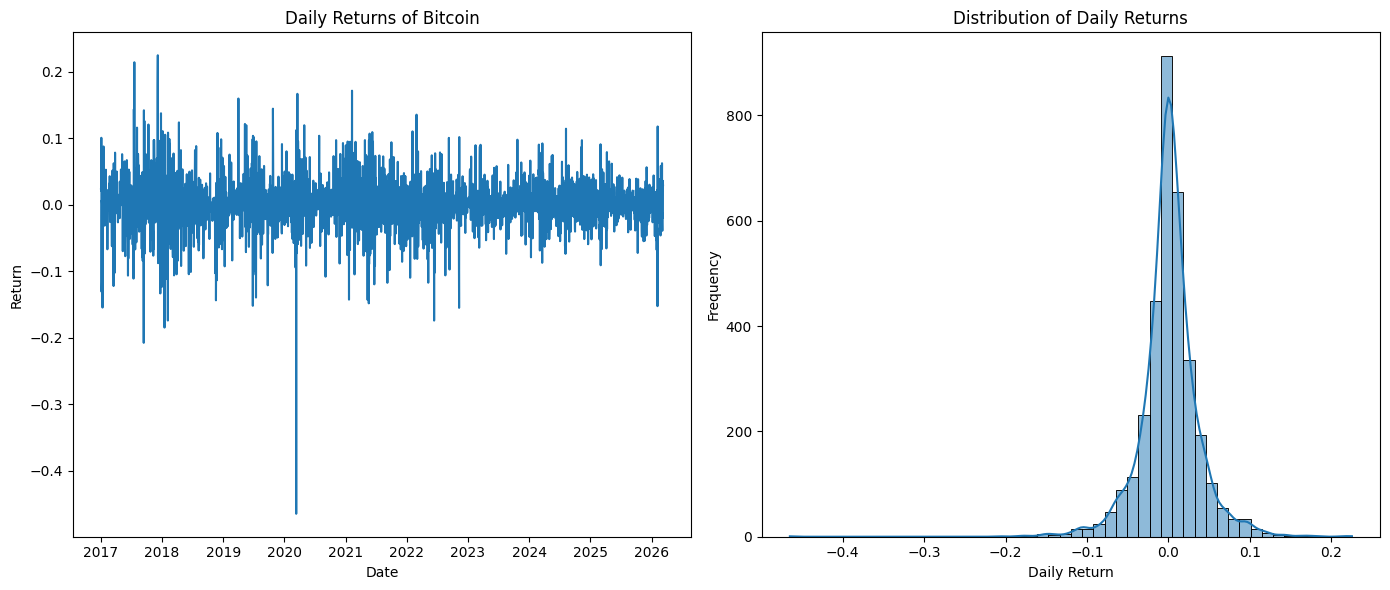

In [10]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Biểu đồ đường
axes[0].plot(df.index, df["daily_return"])
axes[0].set_title("Daily Returns of Bitcoin")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Return")

# Histogram
sns.histplot(df["daily_return"].dropna(), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Daily Returns")
axes[1].set_xlabel("Daily Return")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [11]:
df["daily_return"].kurtosis()

np.float64(11.823719218008748)

Kiểm tra tính dừng (Stationarity - ADF test)

In [14]:
from statsmodels.tsa.stattools import adfuller 

result = adfuller(df["daily_return"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -40.146992586300755
p-value: 0.0
